In [2]:
import pandas as pd
# Sample dataset
data = {
    "Name": ["Alice", "Bob", "Charlie", "David"],
    "Age": [25, 30, 35, 40],
    "Gender":["Female","Male","Male","Male"],
    "Salary":[50000,60000,20000,70000],
    "Joining_Date":["2022-01-01","2021-06-15","2020-03-20","2019-04-23"]
}
df=pd.DataFrame(data)
df

,Name,Age,Gender,Salary,Joining_Date
0,Alice,25,Female,50000,2022-01-01
1,Bob,30,Male,60000,2021-06-15
2,Charlie,35,Male,20000,2020-03-20
3,David,40,Male,70000,2019-04-23


In [3]:
#check data types
df.dtypes

,0
Name,object
Age,int64
Gender,object
Salary,int64
Joining_Date,object


In [4]:
#Handling Numerical Data
#Binning (Discretization)
import pandas as pd
import numpy as np
#sample numerical data
data ={
    "Age":[18,25,30,45,60],
    "Salary":[20000,30000,50000,80000,1500000]
}
df=pd.DataFrame(data)
df

,Age,Salary
0,18,20000
1,25,30000
2,30,50000
3,45,80000
4,60,1500000


In [7]:
#Feature scaling-standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[["Age","Salary"]]=scaler.fit_transform(df[["Age","Salary"]])
df_scaled


,Age,Salary
0,-1.167023,-0.542619
1,-0.702866,-0.525448
2,-0.371325,-0.491105
3,0.623296,-0.439590
4,1.617918,1.998761


In [8]:
#Feature scaling-Normalization(Min-Max)
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
df_normalized=df.copy()
df_normalized[["Age","Salary"]]=scaler.fit_transform(df[["Age","Salary"]])
df_normalized

,Age,Salary
0,0.000000,0.000000
1,0.166667,0.006757
2,0.285714,0.020270
3,0.642857,0.040541
4,1.000000,1.000000


In [9]:
#Log transformation
df_log=df.copy()
df_log["Salary_Log"]=np.log(df_log["Salary"])
df_log

,Age,Salary,Salary_Log
0,18,20000,9.903488
1,25,30000,10.308953
2,30,50000,10.819778
3,45,80000,11.289782
4,60,1500000,14.220976


**Binning (Discretization**)


In [10]:

#create bins for age
bins = [0,20,40,100]
labels = ["Young","Adult","Senior"]
df["Age_Group"] = pd.cut(df["Age"],bins=bins,labels=labels)
df

,Age,Salary,Age_Group
0,18,20000,Young
1,25,30000,Adult
2,30,50000,Adult
3,45,80000,Senior
4,60,1500000,Senior


# **#Handling Categorical Data**

In [12]:
import pandas as pd
data = {
    "Name":["A","B","C","D","E","F"],
    "Gender":["Aale","Female","Female","Male","Zale","Other"],
    "City" : ["Mumbai","Delhi","Mumbai","Pune","Delhi","Delhi"],
    "Performance":["Low","Medium","High","Medium","Low","High"]
}
df=pd.DataFrame(data)
df

,Name,Gender,City,Performance
0,A,Aale,Mumbai,Low
1,B,Female,Delhi,Medium
2,C,Female,Mumbai,High
3,D,Male,Pune,Medium
4,E,Zale,Delhi,Low
5,F,Other,Delhi,High


**Label encoding**

In [13]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["Gender_Label"] = le.fit_transform(df["Gender"])
df["City_Label"] = le.fit_transform(df["City"])
df

,Name,Gender,City,Performance,Gender_Label,City_Label
0,A,Aale,Mumbai,Low,0,1
1,B,Female,Delhi,Medium,1,0
2,C,Female,Mumbai,High,1,1
3,D,Male,Pune,Medium,2,2
4,E,Zale,Delhi,Low,4,0
5,F,Other,Delhi,High,3,0


**Ordinal Encoding**

In [14]:
#Defin order
order = {"Low":3,"Medium":2,"High":1}
df["Performance_Ordinal"]=df["Performance"].map(order)
df

,Name,Gender,City,Performance,Gender_Label,City_Label,Performance_Ordinal
0,A,Aale,Mumbai,Low,0,1,3
1,B,Female,Delhi,Medium,1,0,2
2,C,Female,Mumbai,High,1,1,1
3,D,Male,Pune,Medium,2,2,2
4,E,Zale,Delhi,Low,4,0,3
5,F,Other,Delhi,High,3,0,1


**Frequency Encoding**

In [15]:
freq = df["City"].value_counts()
df["City_Freq"] = df["City"].map(freq)
df

,Name,Gender,City,Performance,Gender_Label,City_Label,Performance_Ordinal,City_Freq
0,A,Aale,Mumbai,Low,0,1,3,2
1,B,Female,Delhi,Medium,1,0,2,3
2,C,Female,Mumbai,High,1,1,1,2
3,D,Male,Pune,Medium,2,2,2,1
4,E,Zale,Delhi,Low,4,0,3,3
5,F,Other,Delhi,High,3,0,1,3


**Target Encoding**

In [16]:
#Create a dummy target variable
df["Target"]=[0,1,1,0,1,2]
#calculate mean target per category
target_mean = df.groupby("City")["Target"].mean()
df["City_Target_Encoded"]=df["City"].map(target_mean)
df

,Name,Gender,City,Performance,Gender_Label,City_Label,Performance_Ordinal,City_Freq,Target,City_Target_Encoded
0,A,Aale,Mumbai,Low,0,1,3,2,0,0.500000
1,B,Female,Delhi,Medium,1,0,2,3,1,1.333333
2,C,Female,Mumbai,High,1,1,1,2,1,0.500000
3,D,Male,Pune,Medium,2,2,2,1,0,0.000000
4,E,Zale,Delhi,Low,4,0,3,3,1,1.333333
5,F,Other,Delhi,High,3,0,1,3,2,1.333333


# **Handling Data & Time Features**

In [18]:
import pandas as pd
data ={
    "Name":["A","B","C"],
    "Joining_Date":["2022-01-15","2021-06-20","2020-12-05"],
}
df=pd.DataFrame(data)
#convert to datetime
df["Joining_Date"]=pd.to_datetime(df["Joining_Date"])
df

,Name,Joining_Date
0,A,2022-01-15
1,B,2021-06-20
2,C,2020-12-05


**Extract Date features**

In [19]:
df["Year"] = df["Joining_Date"].dt.year
df["Month"]=df["Joining_Date"].dt.month
df["Day"]=df["Joining_Date"].dt.day
df["Weekday"]=df["Joining_Date"].dt.day_name()
df

,Name,Joining_Date,Year,Month,Day,Weekday
0,A,2022-01-15,2022,1,15,Saturday
1,B,2021-06-20,2021,6,20,Sunday
2,C,2020-12-05,2020,12,5,Saturday


**Extract Time Features**

In [20]:
df["Full_DateTime"]=pd.to_datetime([
    "2022-01-15 10:30:00",
    "2021-06-20 14:45:00",
    "2020-12-05 08:15:00"
])
df["Hour"]=df["Full_DateTime"].dt.hour
df["Minute"]=df["Full_DateTime"].dt.minute
df

,Name,Joining_Date,Year,Month,Day,Weekday,Full_DateTime,Hour,Minute
0,A,2022-01-15,2022,1,15,Saturday,2022-01-15 10:30:00,10,30
1,B,2021-06-20,2021,6,20,Sunday,2021-06-20 14:45:00,14,45
2,C,2020-12-05,2020,12,5,Saturday,2020-12-05 08:15:00,8,15


**Cyclical Encoding**

In [21]:
import numpy as np
#apply on month
df["Month_sin"]=np.sin(2*np.pi*df["Month"]/12)
df["Month_cos"]=np.cos(2*np.pi*df["Month"]/12)
df

,Name,Joining_Date,Year,Month,Day,Weekday,Full_DateTime,Hour,Minute,Month_sin,Month_cos
0,A,2022-01-15,2022,1,15,Saturday,2022-01-15 10:30:00,10,30,5.000000e-01,0.866025
1,B,2021-06-20,2021,6,20,Sunday,2021-06-20 14:45:00,14,45,1.224647e-16,-1.000000
2,C,2020-12-05,2020,12,5,Saturday,2020-12-05 08:15:00,8,15,-2.449294e-16,1.000000


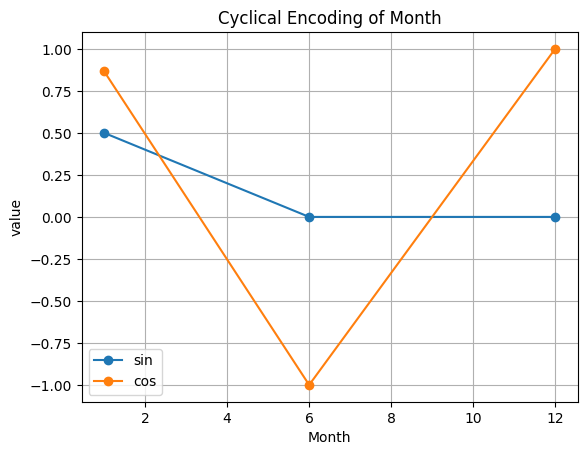

In [22]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(df["Month"], df["Month_sin"],marker='o',label="sin")
plt.plot(df["Month"],df["Month_cos"],marker='o',label="cos")
plt.xlabel("Month")
plt.ylabel("value")
plt.title("Cyclical Encoding of Month")
plt.legend()
plt.grid()
plt.show()

# **Feature creation**

In [25]:
import pandas as pd
data = {
    "Name":["A","B","C"],
    "Price":[100,200,150],
    "Quantity":[2,3,5],
    "First_Name":["John","Jane","Sam"],
    "Last_Name":["Doe","Smith","Brown"],
    "Email":["john@gmail.com","jane@yahoo.com","sam@outlook.com"]
}
df=pd.DataFrame(data)
df

,Name,Price,Quantity,First_Name,Last_Name,Email
0,A,100,2,John,Doe,john@gmail.com
1,B,200,3,Jane,Smith,jane@yahoo.com
2,C,150,5,Sam,Brown,sam@outlook.com


**Mathematical Feature Creation**

In [26]:
df["Total_Price"]=df["Price"] * df["Quantity"]
df

,Name,Price,Quantity,First_Name,Last_Name,Email,Total_Price
0,A,100,2,John,Doe,john@gmail.com,200
1,B,200,3,Jane,Smith,jane@yahoo.com,600
2,C,150,5,Sam,Brown,sam@outlook.com,750


**Combining Feature**

In [27]:
df["Full_Name"]=df["First_Name"]+ " " + df["Last_Name"]
df

,Name,Price,Quantity,First_Name,Last_Name,Email,Total_Price,Full_Name
0,A,100,2,John,Doe,john@gmail.com,200,John Doe
1,B,200,3,Jane,Smith,jane@yahoo.com,600,Jane Smith
2,C,150,5,Sam,Brown,sam@outlook.com,750,Sam Brown


**Extracting Information**

In [30]:
df["Email_Domain"]=df["Email"].apply(lambda x: x.split("@")[1])
df

,Name,Price,Quantity,First_Name,Last_Name,Email,Total_Price,Full_Name,Email_Domain
0,A,100,2,John,Doe,john@gmail.com,200,John Doe,gmail.com
1,B,200,3,Jane,Smith,jane@yahoo.com,600,Jane Smith,yahoo.com
2,C,150,5,Sam,Brown,sam@outlook.com,750,Sam Brown,outlook.com


**Domain-Based Feature**

In [31]:
#example -BMI
df["Weight"]=[60,70,80] #kgs
df["Height"]=[1.6,1.7,1.8] #meters
#BMI formula
df["BMI"]=df["Weight"]/(df["Height"]**2)
df

,Name,Price,Quantity,First_Name,Last_Name,Email,Total_Price,Full_Name,Email_Domain,Weight,Height,BMI
0,A,100,2,John,Doe,john@gmail.com,200,John Doe,gmail.com,60,1.6,23.437500
1,B,200,3,Jane,Smith,jane@yahoo.com,600,Jane Smith,yahoo.com,70,1.7,24.221453
2,C,150,5,Sam,Brown,sam@outlook.com,750,Sam Brown,outlook.com,80,1.8,24.691358


# **Handling Missing Values**

In [32]:
import pandas as pd
import numpy as np
data = {
    "Age":[25,np.nan,30,35,np.nan],
    "Salary":[50000,60000,np.nan,80000,90000],
    "City":["Mumbai","Delhi",None,"Pune","Delhi"]
}
df=pd.DataFrame(data)
df

,Age,Salary,City
0,25.0,50000.0,Mumbai
1,NaN,60000.0,Delhi
2,30.0,NaN,None
3,35.0,80000.0,Pune
4,NaN,90000.0,Delhi


In [33]:
#checking missing values
df.isnull().sum()

,0
Age,2
Salary,1
City,1


**Mean Imputation**

In [34]:
df2=df.copy()
df2["Age"].fillna(df2["Age"].mean(),inplace=True)
df2

/tmp/ipykernel_870/2540756503.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2["Age"].fillna(df2["Age"].mean(),inplace=True)


,Age,Salary,City
0,25.0,50000.0,Mumbai
1,30.0,60000.0,Delhi
2,30.0,NaN,None
3,35.0,80000.0,Pune
4,30.0,90000.0,Delhi


**Median Imputation**

In [37]:
df2=df.copy()
df2["Salary"] = df2["Salary"].fillna(df2["Salary"].median())
df2

,Age,Salary,City
0,25.0,50000.0,Mumbai
1,NaN,60000.0,Delhi
2,30.0,70000.0,None
3,35.0,80000.0,Pune
4,NaN,90000.0,Delhi


**Mode Imputation**

In [42]:
df2=df.copy()
df2["City"]=df2["City"].fillna(df2["City"].mode()[0])
df2

,Age,Salary,City
0,25.0,50000.0,Mumbai
1,NaN,60000.0,Delhi
2,30.0,NaN,Delhi
3,35.0,80000.0,Pune
4,NaN,90000.0,Delhi


**Forward Fill**

In [43]:
df_ffill= df.fillna(method="ffill")
df_ffill

/tmp/ipykernel_870/2404721961.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_ffill= df.fillna(method="ffill")


,Age,Salary,City
0,25.0,50000.0,Mumbai
1,25.0,60000.0,Delhi
2,30.0,60000.0,Delhi
3,35.0,80000.0,Pune
4,35.0,90000.0,Delhi


**Backward Fill**

In [44]:
df_bfill = df.fillna(method="bfill")
df_bfill

/tmp/ipykernel_870/1714158225.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_bfill = df.fillna(method="bfill")


,Age,Salary,City
0,25.0,50000.0,Mumbai
1,30.0,60000.0,Delhi
2,30.0,80000.0,Pune
3,35.0,80000.0,Pune
4,NaN,90000.0,Delhi


**Missing Indicator**

In [45]:
df["Age_missing"] = df["Age"].isnull().astype(int)
df

,Age,Salary,City,Age_missing
0,25.0,50000.0,Mumbai,0
1,NaN,60000.0,Delhi,1
2,30.0,NaN,None,0
3,35.0,80000.0,Pune,0
4,NaN,90000.0,Delhi,1


# **Feature Selection**

In [46]:
import pandas as pd
data = {
    "Age": [25,30,35,40,45],
    "Salary":[30000,40000,50000,60000,70000],\
    "Experience":[1,3,5,7,9],
    "Purchased":[0,0,1,1,1] #Target variable
}
df=pd.DataFrame(data)
df

,Age,Salary,Experience,Purchased
0,25,30000,1,0
1,30,40000,3,0
2,35,50000,5,1
3,40,60000,7,1
4,45,70000,9,1


**Correlation (Filter Method)**

In [47]:
df.corr()

,Age,Salary,Experience,Purchased
Age,1.000000,1.000000,1.000000,0.866025
Salary,1.000000,1.000000,1.000000,0.866025
Experience,1.000000,1.000000,1.000000,0.866025
Purchased,0.866025,0.866025,0.866025,1.000000


Select Important Features (based on correlation)

In [48]:
#correlation with target
corr_with_target = df.corr()["Purchased"]
corr_with_target

,Purchased
Age,0.866025
Salary,0.866025
Experience,0.866025
Purchased,1.000000


**Drop less important Features**

In [49]:
df_selected = df.drop(columns=["Age"])
df_selected

,Salary,Experience,Purchased
0,30000,1,0
1,40000,3,0
2,50000,5,1
3,60000,7,1
4,70000,9,1


# **Handling Outliers**

In [50]:
import pandas as pd
data = {
    "Salary" : [30000,35000,40000,50000,100000] #outlier present
}
df = pd.DataFrame(data)
df

,Salary
0,30000
1,35000
2,40000
3,50000
4,100000


**Detect Outliers using IQR**

In [51]:
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)
IRQ = Q3-Q1
lower_bound = Q1-1.5*IRQ
upper_bound = Q3-1.5*IRQ
lower_bound,upper_bound
#Detect outlier
outliers = df[(df["Salary"]<lower_bound) | (df["Salary"]> upper_bound)]
print(outliers)

   Salary
0   30000
1   35000
2   40000
3   50000
4  100000


**Identify Outliers**

In [52]:
outliers = df[(df["Salary"]<lower_bound)|(df["Salary"]>upper_bound)]
outliers

,Salary
0,30000
1,35000
2,40000
3,50000
4,100000


**Remove outliers**

In [54]:
df_no_outliers = df[(df["Salary"]>=lower_bound)&(df["Salary"]<=upper_bound)]
df_no_outliers

,Salary


**cap outliers**

In [55]:
df_capped = df.copy()
df_capped["Salary"]=df_capped["Salary"].clip(lower_bound, upper_bound)
df_capped

,Salary
0,27500
1,27500
2,27500
3,27500
4,27500


**Z-Score Method**

In [56]:
from scipy import stats
z_scores = stats.zscore(df["Salary"])
z_scores

array([-0.82751593, -0.63048832, -0.43346072, -0.03940552,  1.9308705 ])

**Identify Outliers using z-score**

In [57]:
df_z = df[(abs(z_scores)>2)]
df_z

,Salary
